<a href="https://colab.research.google.com/github/marcelalozano27-ship-it/Text-analytics-practice-/blob/main/CRM_Assignment_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load the Dataset and Understand the Business Problem

In [36]:
#Load the data from github link
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('https://raw.githubusercontent.com/nailson/ifood-data-business-analyst-test/master/ifood_df.csv')

In [37]:
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


The objective of this analysis is to improve the profitability of iFood's next direct marketing campaign. The company's last pilot campaign contacted 2,240 customers with a 15% response rate. However, the campaign had an overall negative profit due to a lack of optimization of the customers they are contacting.

In [38]:
#Exploratory data analysis
df.shape

(2205, 39)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [40]:
df.isnull().sum()

,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0
MntGoldProds,0


In [41]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


In [42]:
df["Response"].value_counts(normalize=True)

,proportion
Response,
0,0.84898
1,0.15102


Approximately 15% of customers accepted the previous campaign offer confirming that the company is not properly targeting.

Customers that actually accepted the campaign also tend to have higher income levels so purchasing power is likely an important factor in conversion likelihood.

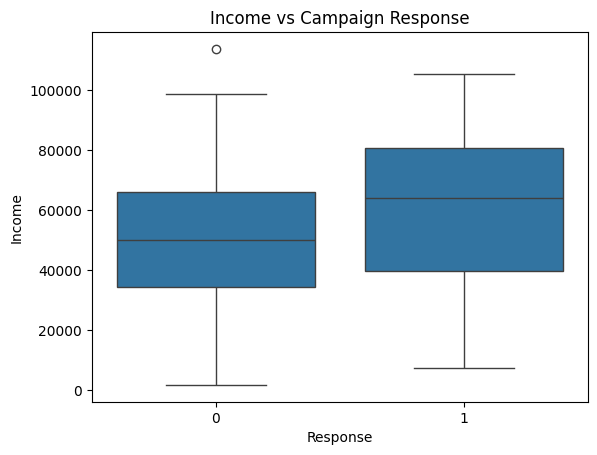

In [43]:
sns.boxplot(x="Response", y="Income", data=df)
plt.title("Income vs Campaign Response")
plt.show()

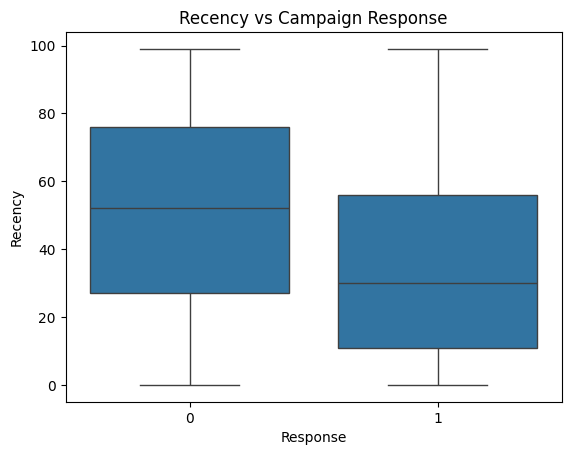

In [44]:
sns.boxplot(x="Response", y="Recency", data=df)
plt.title("Recency vs Campaign Response")
plt.show()

Customers that have purchased more recently are more likely to respond to marketing campaigns.

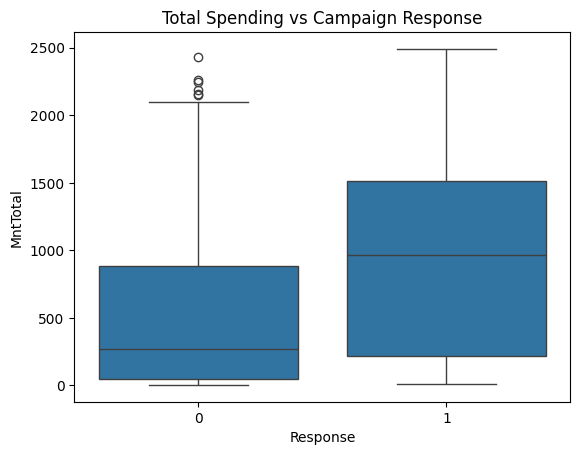

In [45]:
sns.boxplot(x="Response", y="MntTotal", data=df)
plt.title("Total Spending vs Campaign Response")
plt.show()

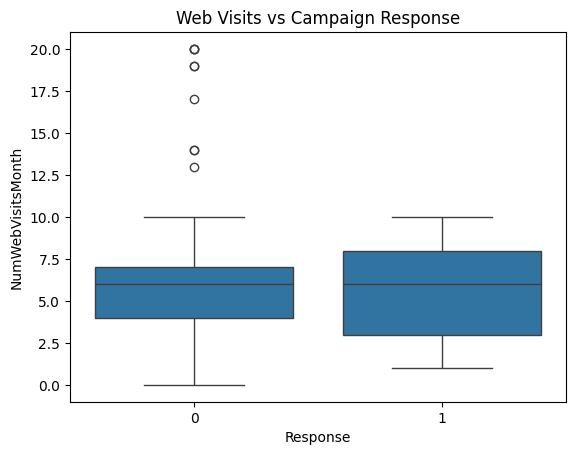

In [46]:
sns.boxplot(x="Response", y="NumWebVisitsMonth", data=df)
plt.title("Web Visits vs Campaign Response")
plt.show()

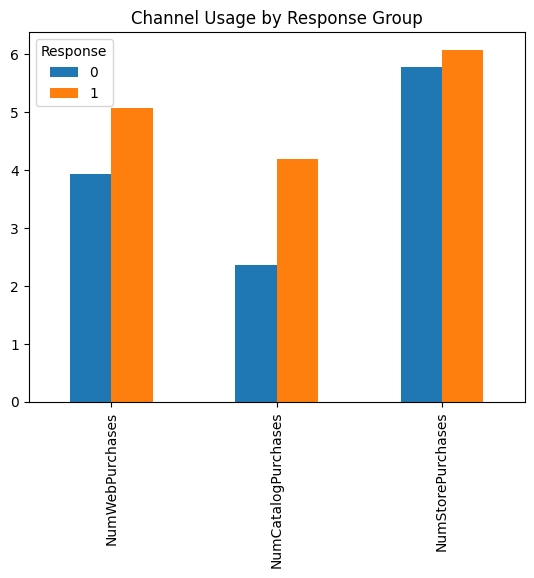

In [47]:
channel_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

df.groupby("Response")[channel_cols].mean().T.plot(kind="bar")
plt.title("Channel Usage by Response Group")
plt.show()

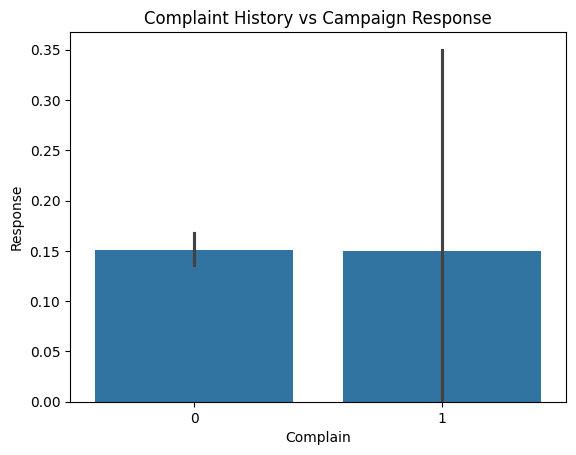

In [48]:
sns.barplot(x="Complain", y="Response", data=df)
plt.title("Complaint History vs Campaign Response")
plt.show()

In [49]:
cluster_features = [
    "Income",
    "Recency",
    "MntTotal",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "AcceptedCmpOverall",
    "Customer_Days"
]

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[cluster_features])

Cluster Analysis

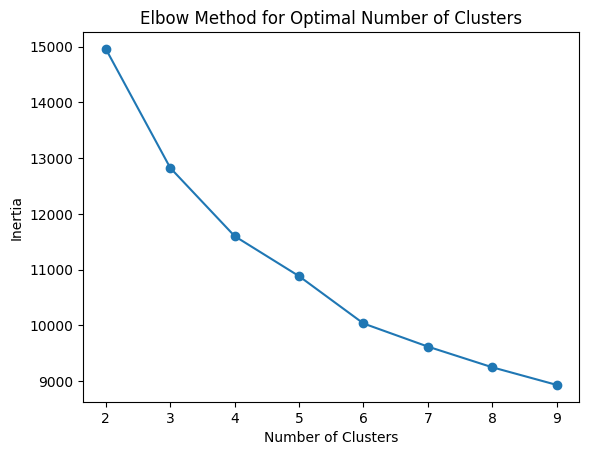

In [51]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [52]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_features)

In [53]:
cluster_profile = df.groupby("Cluster")[cluster_features].mean()
cluster_profile

,Income,Recency,MntTotal,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,AcceptedCmpOverall,Customer_Days
Cluster,,,,,,,,,,
0,81482.704000,49.368000,1530.664000,5.552000,6.264000,8.096000,1.152000,3.408000,2.520000,2515.176000
1,53203.963597,49.156317,618.218415,6.616702,2.655246,7.044968,4.706638,6.719486,0.235546,2630.743041
2,34291.669688,48.849950,77.846928,2.029204,0.549849,3.201410,1.883182,6.373615,0.086606,2472.593152
3,72166.938710,49.080645,1102.504839,5.230645,5.264516,8.645161,1.451613,3.024194,0.240323,2487.588710


In [54]:
df.groupby("Cluster")["Response"].mean()

,Response
Cluster,
0,0.648000
1,0.169165
2,0.084592
3,0.143548


Cluster Analysis Breakdown:
- Cluster 0: High Value Loyal Customers
- Cluster 1: Discount Sensitive Customers
- Cluster 2: Low Engagement Customers
- Cluster 3: Digital Browsers

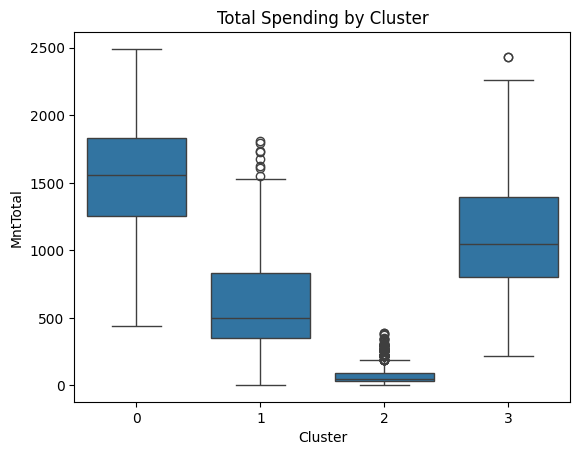

In [55]:
import seaborn as sns

sns.boxplot(x="Cluster", y="MntTotal", data=df)
plt.title("Total Spending by Cluster")
plt.show()

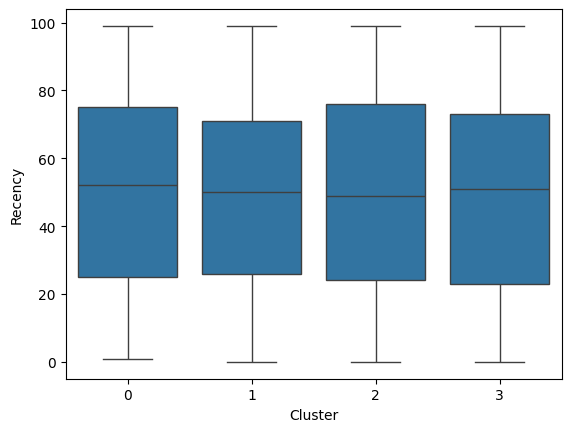

In [56]:
sns.boxplot(x="Cluster", y="Recency", data=df)
plt.show()

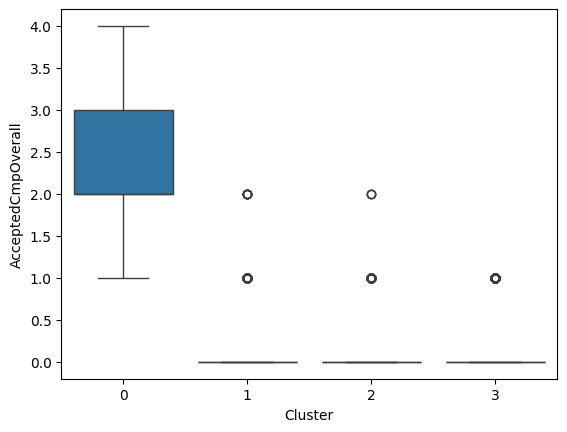

In [57]:
sns.boxplot(x="Cluster", y="AcceptedCmpOverall", data=df)
plt.show()

In [58]:
X = df.drop(columns=["Response"])
y = df["Response"]

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [60]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [61]:
from sklearn.metrics import roc_auc_score

y_pred_prob = model.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, y_pred_prob)

np.float64(0.8255249110320284)

In [62]:
df["conversion_probability"] = model.predict_proba(X)[:, 1]

In [63]:
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Cluster,conversion_probability
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,1,0,0,1529,1441,0,1,0.800595
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,1,0,0,21,15,0,2,0.067403
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,1,0,0,734,692,0,3,0.030004
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,1,0,0,48,43,0,2,0.098546
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,1,407,392,0,1,0.024449


We are defining campaign economics given the case study data:
Cost=6720 MU
Revenue= 3674 MU
Customers = 2240

In [64]:
contact_cost = 6720 / 2240
revenue_per_conversion = 3674 / (2240 * 0.15)

In [65]:
df["expected_profit"] = (
    df["conversion_probability"] * revenue_per_conversion
    - contact_cost
)

In [66]:
# We are now calculating the break even point to ensure no customers with a potential negative profit are reached out to

threshold = contact_cost / revenue_per_conversion
threshold

0.27436037016875336

In [69]:
target_customers = df[df["conversion_probability"] > threshold]
len(target_customers)

373

There are about 373 customers out of the 2,240 that given our model prediction, should be prioritized for the campaign outreach.

We calculated the break even probability by dividing the contact cost by the revenue and if this number is larger than 0.274 then we can consider the customer to have a high probability of generating a positive return.

In [70]:
target_customers["expected_profit"].sum()

np.float64(890.474035794475)

By targeting on the customers predicted to have a positive outcome, the profit from the campaign is expected to be positive.

In [72]:
target_customers["conversion_probability"].mean()

np.float64(0.4926899377167748)

Additionally the conversion probability increases from 15% to 49% which is a much more effective use of outreach.

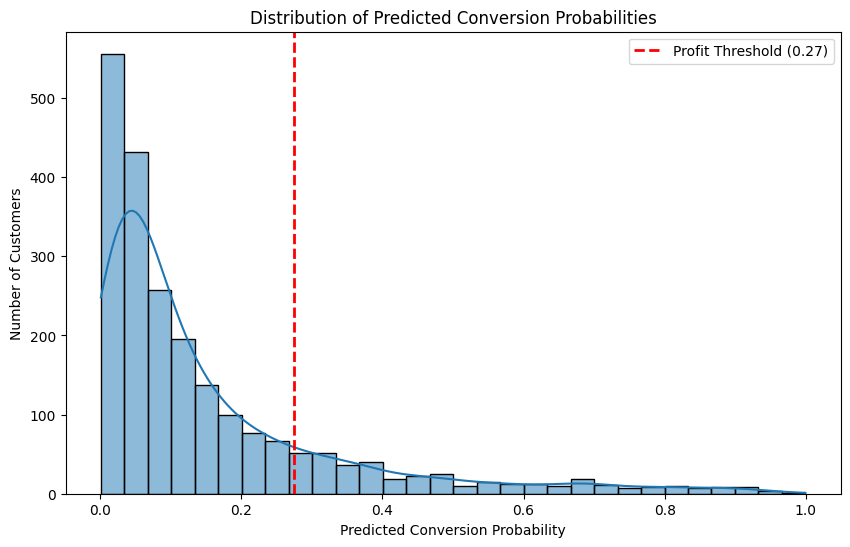

In [74]:

plt.figure(figsize=(10,6))

sns.histplot(
    df["conversion_probability"],
    bins=30,
    kde=True
)

plt.axvline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Profit Threshold ({threshold:.2f})"
)

plt.title("Distribution of Predicted Conversion Probabilities")
plt.xlabel("Predicted Conversion Probability")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

In [75]:
feature_importance = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

feature_importance.head(10)

,0
NumStorePurchases,-0.376510
Cluster,-0.169950
AcceptedCmpOverall,0.167594
NumCatalogPurchases,0.120814
Z_Revenue,-0.116450
NumWebVisitsMonth,0.107734
NumWebPurchases,0.099997
AcceptedCmp3,0.059214
AcceptedCmp5,0.043965
marital_Married,-0.038414


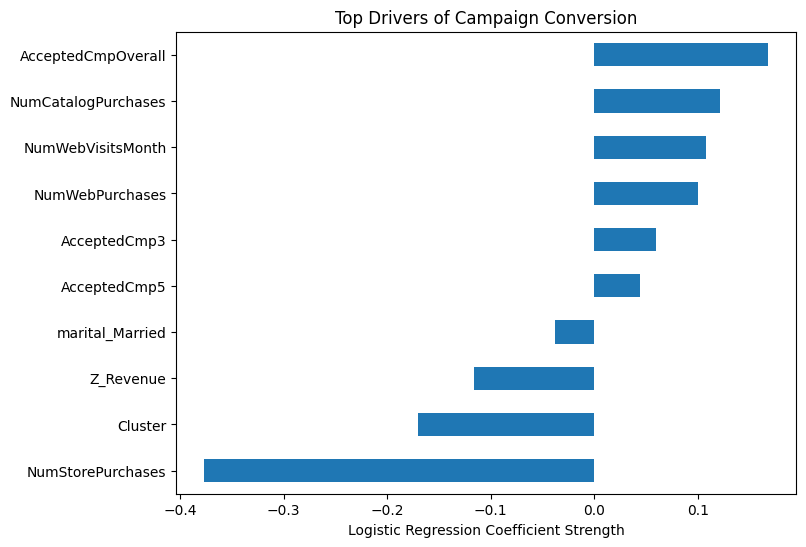

In [76]:


top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind="barh")

plt.title("Top Drivers of Campaign Conversion")
plt.xlabel("Logistic Regression Coefficient Strength")
plt.show()

In [77]:
feature_importance.sort_values(ascending=False).head(10)

,0
AcceptedCmpOverall,0.167594
NumCatalogPurchases,0.120814
NumWebVisitsMonth,0.107734
NumWebPurchases,0.099997
AcceptedCmp3,0.059214
AcceptedCmp5,0.043965
AcceptedCmp1,0.037448
education_PhD,0.030317
NumDealsPurchases,0.029862
marital_Single,0.029420


In [78]:
feature_importance.sort_values().head(10)

,0
NumStorePurchases,-0.376510
Cluster,-0.169950
Z_Revenue,-0.116450
marital_Married,-0.038414
Teenhome,-0.034013
marital_Together,-0.032084
Z_CostContact,-0.031759
Recency,-0.030186
education_Graduation,-0.027038
Age,-0.020339


In [80]:
df.groupby("Cluster").agg({
    "conversion_probability":"mean",
    "MntTotal":"mean",
    "Recency":"mean",
    "Income":"mean"
}).round(2)

,conversion_probability,MntTotal,Recency,Income
Cluster,,,,
0,0.43,1530.66,49.37,81482.70
1,0.17,618.22,49.16,53203.96
2,0.11,77.85,48.85,34291.67
3,0.16,1102.50,49.08,72166.94
